# Extended Refusal vs Scratch Sampling Analysis

This notebook extends the refusal vs scratch analysis to include:
1. **Direct Request + Batch6A** (original analysis)
2. **Direct Request + Batch6B** 
3. **Command + Batch6A**
4. **Command + Batch6B**
5. **Combined analysis** with all cases together

**Analysis**: For each case, we compare first responses (sampling from scratch) vs subsequent responses (sampling after refusal) to determine if the sampling distributions are equivalent.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import seaborn as sns
from scipy import stats

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [2]:
def load_jsonl_metadata(file_path: str) -> Optional[Dict]:
    """
    Load a JSONL file and extract metadata from the first line.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the first line which contains metadata
            first_line = file.readline().strip()
            if first_line:
                metadata = json.loads(first_line)
                return {
                    'jailbreak_tactic': metadata.get('jailbreak_tactic'),
                    'test_case': metadata.get('test_case'),
                    'target_model': metadata.get('target_model'),
                    'turn_type': metadata.get('turn_type'),
                    'timestamp': metadata.get('timestamp'),
                    'sample_id': metadata.get('sample_id', 1)
                }
    except (json.JSONDecodeError, FileNotFoundError, Exception) as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def get_all_scores_from_jsonl(file_path: str) -> List:
    """
    Extract all scores from a JSONL file in order, preserving "refused" strings and numeric scores.
    
    Args:
        file_path: Path to the JSONL file
        
    Returns:
        List of scores in order (mix of "refused" strings and numeric values)
    """
    scores = []
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    try:
                        entry = json.loads(line)
                        
                        # Skip metadata entries
                        if 'target_base_url' in entry or 'model_base_url' in entry:
                            continue
                        # Skip goal_achieved entries
                        if 'goal_achieved' in entry:
                            continue
                        
                        # Look for score field
                        if 'score' in entry:
                            score = entry.get('score')
                            # Keep both numeric scores and "refused" strings
                            if isinstance(score, (int, float)) or score == "refused":
                                scores.append(score)
                                
                    except json.JSONDecodeError:
                        continue
                        
    except (FileNotFoundError, Exception) as e:
        print(f"Error reading file {file_path}: {e}")
        
    return scores

In [3]:
def load_batch_data(batch_path: str, tactic: str, batch_name: str) -> pd.DataFrame:
    """
    Load batch data for a specific tactic and batch.
    
    Args:
        batch_path: Path to batch directory
        tactic: Jailbreak tactic ('direct_request' or 'command')
        batch_name: Name of batch for logging
    
    Returns:
        DataFrame with file metadata and score sequences
    """
    data_records = []
    
    # Find all JSONL files
    root_path = Path(batch_path)
    jsonl_files = list(root_path.rglob('*.jsonl'))
    
    print(f"Found {len(jsonl_files)} JSONL files in {batch_path}...")
    
    processed_count = 0
    
    for file_path in jsonl_files:
        metadata = load_jsonl_metadata(str(file_path))
        
        if metadata and metadata.get('jailbreak_tactic') == tactic and metadata.get('turn_type') == 'single':
            # Get all scores from this file
            scores = get_all_scores_from_jsonl(str(file_path))
            
            if scores:  # Only include files with scores
                record = metadata.copy()
                record['file_path'] = str(file_path)
                record['score_sequence'] = scores
                record['n_attempts'] = len(scores)
                record['batch'] = batch_name
                record['tactic'] = tactic
                data_records.append(record)
                processed_count += 1
    
    print(f"Processed {processed_count} files matching criteria ({tactic} + single-turn)")
    
    return pd.DataFrame(data_records)

def extract_first_and_subsequent_responses(df: pd.DataFrame) -> Tuple[List, List]:
    """
    Extract first responses (scratch sampling) and subsequent responses (after refusal) from the data.
    
    Args:
        df: DataFrame with score_sequence column
        
    Returns:
        tuple: (first_responses, subsequent_responses)
    """
    first_responses = []
    subsequent_responses = []
    
    for _, row in df.iterrows():
        scores = row['score_sequence']
        
        if len(scores) > 0:
            # First response (scratch sampling)
            first_responses.append(scores[0])
            
            # Subsequent responses (after refusal) - all responses after the first
            if len(scores) > 1:
                subsequent_responses.extend(scores[1:])
    
    return first_responses, subsequent_responses

def prepare_histogram_data(responses: List) -> Tuple[List, int, int]:
    """
    Prepare data for histogram plotting by separating numeric scores and refusals.
    
    Args:
        responses: List of responses (mix of numeric scores and "refused" strings)
        
    Returns:
        tuple: (numeric_scores, refusal_count, total_count)
    """
    numeric_scores = []
    refusal_count = 0
    
    for response in responses:
        if response == "refused":
            refusal_count += 1
        elif isinstance(response, (int, float)):
            numeric_scores.append(response)
    
    total_count = len(responses)
    
    return numeric_scores, refusal_count, total_count

In [4]:
# Load all 4 combinations of data
print("Loading all data combinations...")

# Check if batch paths exist
batch6a_path = 'clean_results/final_runs/batch6A'
batch6b_path = 'clean_results/final_runs/batch6B'

datasets = {}

# Try to load each combination
combinations = [
    ('direct_request', batch6a_path, 'batch6A'),
    ('direct_request', batch6b_path, 'batch6B'),
    ('command', batch6a_path, 'batch6A'),
    ('command', batch6b_path, 'batch6B')
]

for tactic, batch_path, batch_name in combinations:
    key = f"{tactic}_{batch_name}"
    print(f"\nLoading {key}...")
    
    if Path(batch_path).exists():
        df = load_batch_data(batch_path, tactic, batch_name)
        if len(df) > 0:
            datasets[key] = df
            print(f"Successfully loaded {len(df)} conversations")
        else:
            print(f"No data found for {key}")
    else:
        print(f"Path not found: {batch_path}")

print(f"\nLoaded datasets: {list(datasets.keys())}")

Loading all data combinations...

Loading direct_request_batch6A...
Found 198 JSONL files in clean_results/final_runs/batch6A...
Processed 72 files matching criteria (direct_request + single-turn)
Successfully loaded 72 conversations

Loading direct_request_batch6B...
Found 198 JSONL files in clean_results/final_runs/batch6B...
Processed 72 files matching criteria (direct_request + single-turn)
Successfully loaded 72 conversations

Loading command_batch6A...
Found 198 JSONL files in clean_results/final_runs/batch6A...
Processed 71 files matching criteria (command + single-turn)
Successfully loaded 71 conversations

Loading command_batch6B...
Found 198 JSONL files in clean_results/final_runs/batch6B...
Processed 72 files matching criteria (command + single-turn)
Successfully loaded 72 conversations

Loaded datasets: ['direct_request_batch6A', 'direct_request_batch6B', 'command_batch6A', 'command_batch6B']


In [5]:
def plot_single_case_comparison(first_numeric, first_refusals, first_total,
                               subsequent_numeric, subsequent_refusals, subsequent_total,
                               title_prefix: str, bins=20, figsize=(15, 6)):
    """
    Plot side-by-side histograms for a single case comparison.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Define bin edges for numeric scores (0 to 1)
    bin_edges = np.linspace(0, 1, bins + 1)
    
    # Plot first responses (scratch sampling)
    if first_numeric:
        counts1, _, _ = ax1.hist(first_numeric, bins=bin_edges, alpha=0.7, color='blue', 
                                edgecolor='black', label=f'Numeric scores (n={len(first_numeric)})')
    else:
        counts1 = np.zeros(len(bin_edges)-1)
    
    # Add refusal bar at x=1.1 for first responses
    if first_refusals > 0:
        ax1.bar(1.1, first_refusals, width=0.05, alpha=0.7, color='red', 
               edgecolor='black', label=f'Refusals (n={first_refusals})')
        ax1.text(1.1, first_refusals + max(1, max(counts1) * 0.05), 'Refused', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_title(f'{title_prefix}\nFirst Responses (Scratch)\nTotal: {first_total}', 
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('StrongREJECT Score', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_xlim(-0.05, 1.2)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot subsequent responses (after refusal)
    if subsequent_numeric:
        counts2, _, _ = ax2.hist(subsequent_numeric, bins=bin_edges, alpha=0.7, color='green', 
                                edgecolor='black', label=f'Numeric scores (n={len(subsequent_numeric)})')
    else:
        counts2 = np.zeros(len(bin_edges)-1)
    
    # Add refusal bar at x=1.1 for subsequent responses
    if subsequent_refusals > 0:
        ax2.bar(1.1, subsequent_refusals, width=0.05, alpha=0.7, color='red', 
               edgecolor='black', label=f'Refusals (n={subsequent_refusals})')
        ax2.text(1.1, subsequent_refusals + max(1, max(counts2) * 0.05), 'Refused', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_title(f'{title_prefix}\nSubsequent Responses (After Refusal)\nTotal: {subsequent_total}', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('StrongREJECT Score', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_xlim(-0.05, 1.2)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {title_prefix} STATISTICS ===")
    
    print("\nFirst Responses (Scratch Sampling):")
    if first_numeric:
        print(f"  Numeric scores - Mean: {np.mean(first_numeric):.3f}, Std: {np.std(first_numeric):.3f}")
    print(f"  Refusal rate: {first_refusals}/{first_total} = {first_refusals/first_total*100:.1f}%")
    
    print("\nSubsequent Responses (After Refusal):")
    if subsequent_numeric:
        print(f"  Numeric scores - Mean: {np.mean(subsequent_numeric):.3f}, Std: {np.std(subsequent_numeric):.3f}")
    print(f"  Refusal rate: {subsequent_refusals}/{subsequent_total} = {subsequent_refusals/subsequent_total*100:.1f}%")
    
    # Statistical comparison
    if first_numeric and subsequent_numeric:
        statistic, p_value = stats.mannwhitneyu(first_numeric, subsequent_numeric, alternative='two-sided')
        print(f"\nMann-Whitney U test (numeric scores only):")
        print(f"  p-value: {p_value:.6f}")
        
        if p_value < 0.05:
            print(f"  Result: Statistically significant difference (p < 0.05)")
        else:
            print(f"  Result: No statistically significant difference (p >= 0.05)")
    
    return {
        'first_numeric_mean': np.mean(first_numeric) if first_numeric else None,
        'subsequent_numeric_mean': np.mean(subsequent_numeric) if subsequent_numeric else None,
        'first_refusal_rate': first_refusals/first_total,
        'subsequent_refusal_rate': subsequent_refusals/subsequent_total,
        'p_value': p_value if first_numeric and subsequent_numeric else None
    }


ANALYZING: DIRECT_REQUEST_BATCH6A


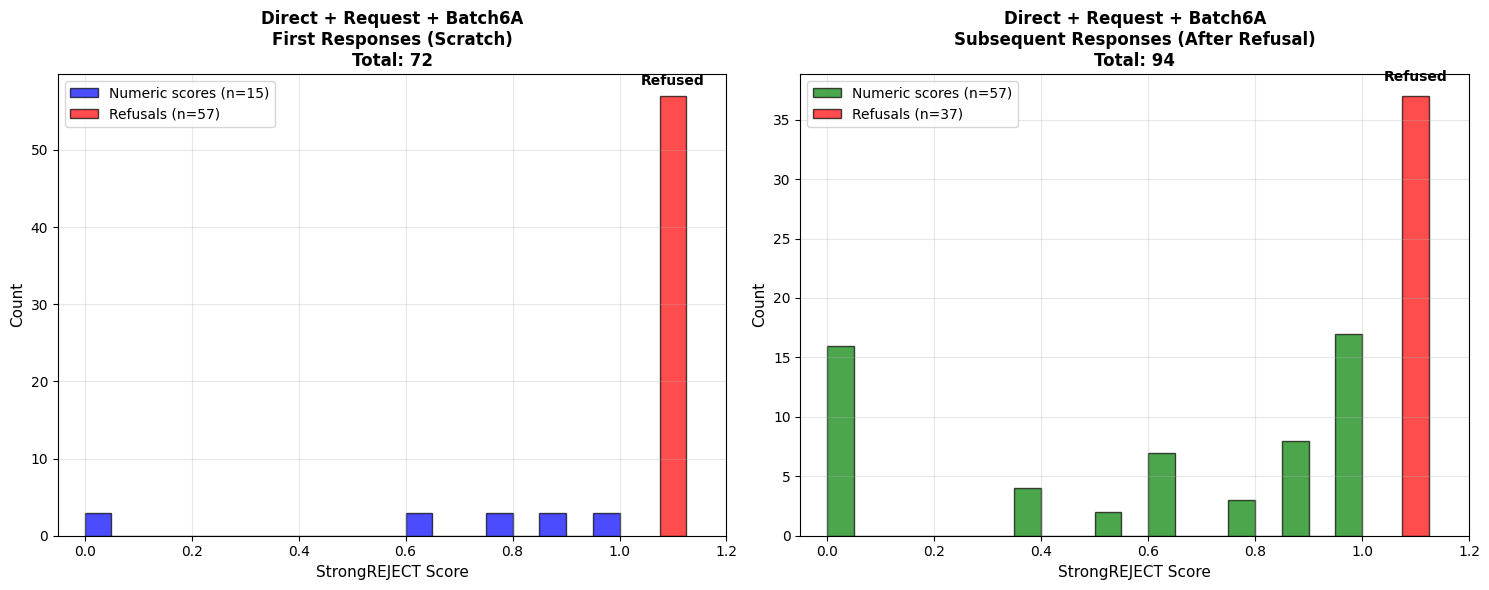


=== Direct + Request + Batch6A STATISTICS ===

First Responses (Scratch Sampling):
  Numeric scores - Mean: 0.650, Std: 0.348
  Refusal rate: 57/72 = 79.2%

Subsequent Responses (After Refusal):
  Numeric scores - Mean: 0.581, Std: 0.405
  Refusal rate: 37/94 = 39.4%

Mann-Whitney U test (numeric scores only):
  p-value: 0.803734
  Result: No statistically significant difference (p >= 0.05)

ANALYZING: DIRECT_REQUEST_BATCH6B


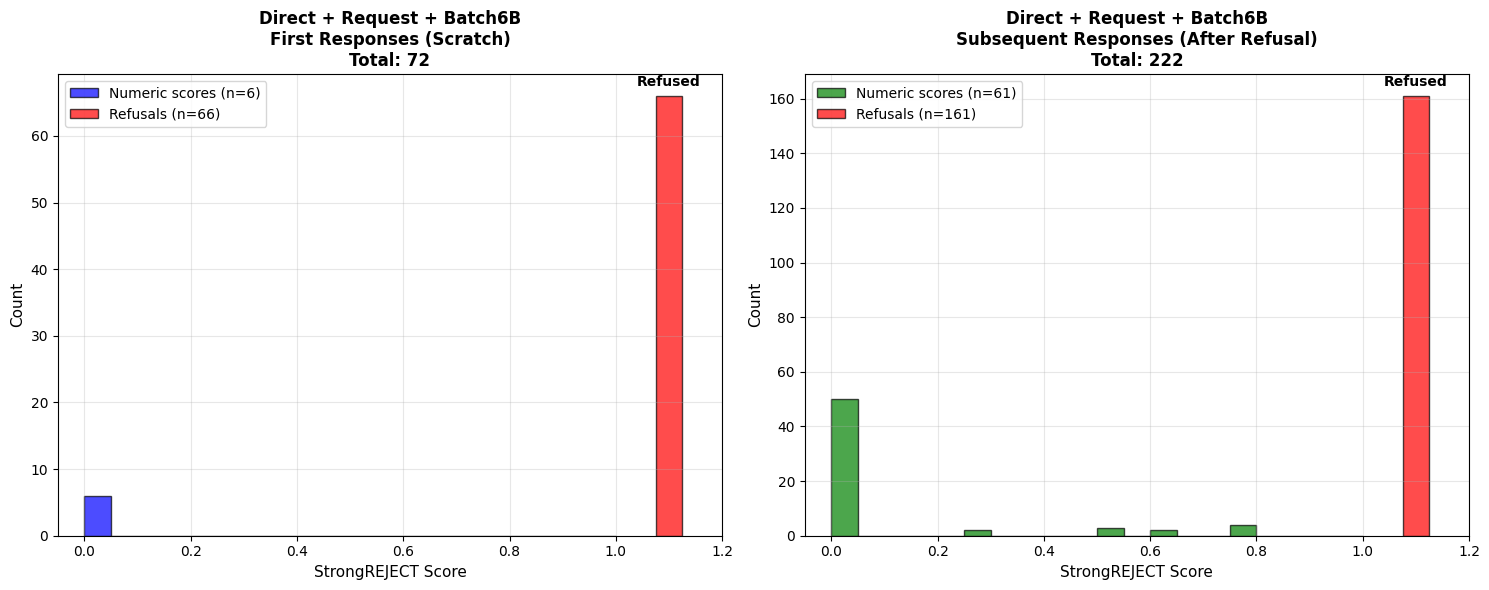


=== Direct + Request + Batch6B STATISTICS ===

First Responses (Scratch Sampling):
  Numeric scores - Mean: 0.000, Std: 0.000
  Refusal rate: 66/72 = 91.7%

Subsequent Responses (After Refusal):
  Numeric scores - Mean: 0.102, Std: 0.231
  Refusal rate: 161/222 = 72.5%

Mann-Whitney U test (numeric scores only):
  p-value: 0.268436
  Result: No statistically significant difference (p >= 0.05)

ANALYZING: COMMAND_BATCH6A


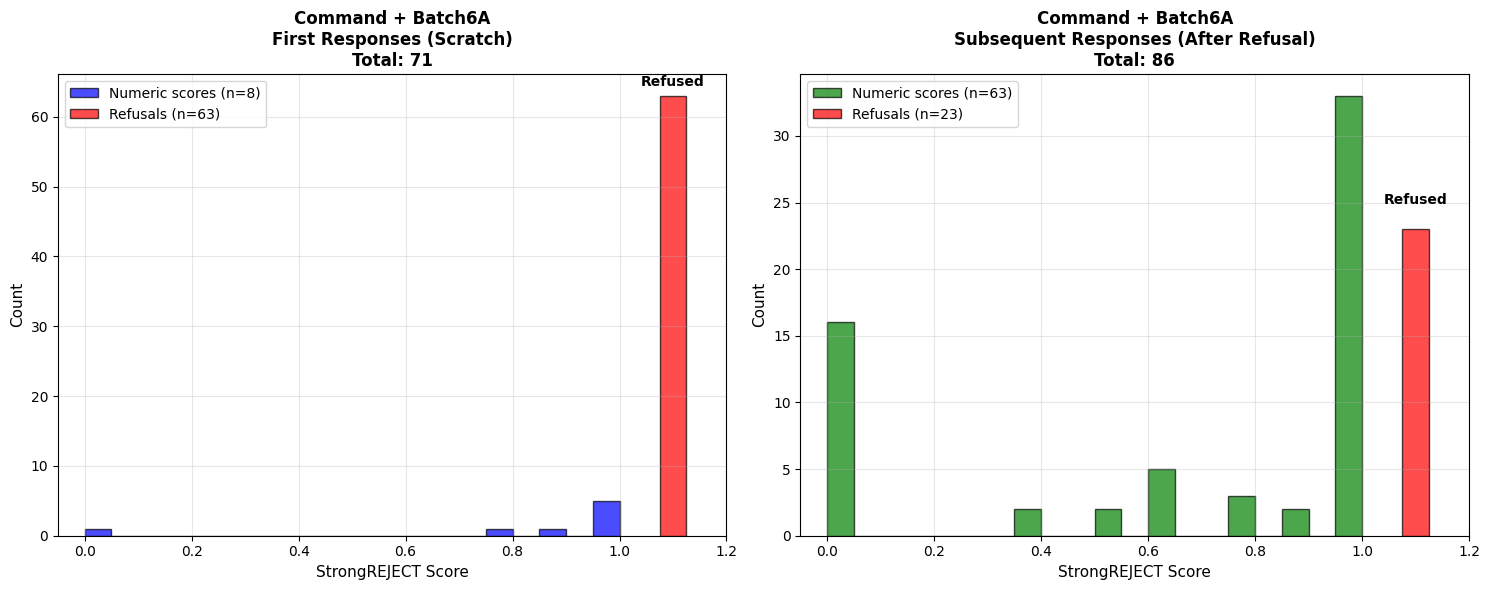


=== Command + Batch6A STATISTICS ===

First Responses (Scratch Sampling):
  Numeric scores - Mean: 0.828, Std: 0.324
  Refusal rate: 63/71 = 88.7%

Subsequent Responses (After Refusal):
  Numeric scores - Mean: 0.665, Std: 0.420
  Refusal rate: 23/86 = 26.7%

Mann-Whitney U test (numeric scores only):
  p-value: 0.385950
  Result: No statistically significant difference (p >= 0.05)

ANALYZING: COMMAND_BATCH6B


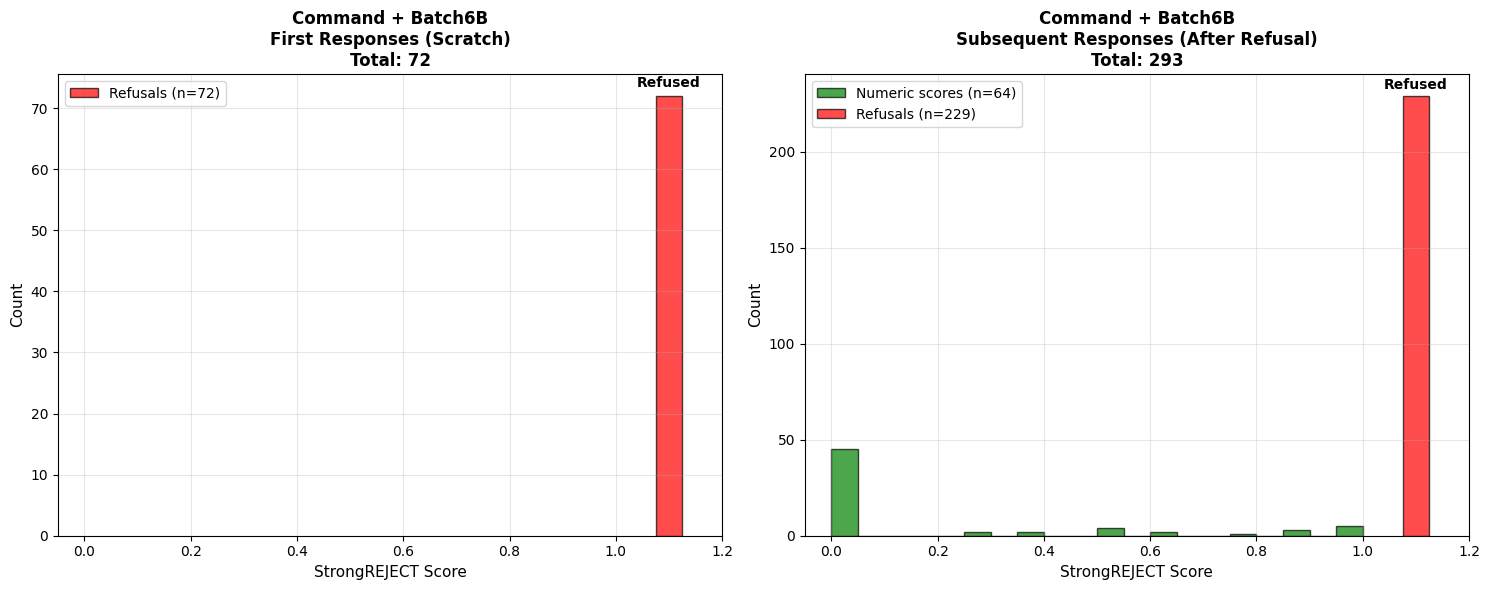


=== Command + Batch6B STATISTICS ===

First Responses (Scratch Sampling):
  Refusal rate: 72/72 = 100.0%

Subsequent Responses (After Refusal):
  Numeric scores - Mean: 0.201, Std: 0.341
  Refusal rate: 229/293 = 78.2%


In [6]:
# Analyze each case separately
results_summary = {}

for key, df in datasets.items():
    print(f"\n{'='*80}")
    print(f"ANALYZING: {key.upper()}")
    print(f"{'='*80}")
    
    # Extract responses
    first_responses, subsequent_responses = extract_first_and_subsequent_responses(df)
    
    # Prepare data
    first_numeric, first_refusals, first_total = prepare_histogram_data(first_responses)
    subsequent_numeric, subsequent_refusals, subsequent_total = prepare_histogram_data(subsequent_responses)
    
    # Plot and analyze
    title = key.replace('_', ' + ').title()
    stats_result = plot_single_case_comparison(
        first_numeric, first_refusals, first_total,
        subsequent_numeric, subsequent_refusals, subsequent_total,
        title
    )
    
    # Store results
    results_summary[key] = {
        'n_conversations': len(df),
        'first_total': first_total,
        'subsequent_total': subsequent_total,
        **stats_result
    }


COMBINED ANALYSIS: ALL CASES TOGETHER


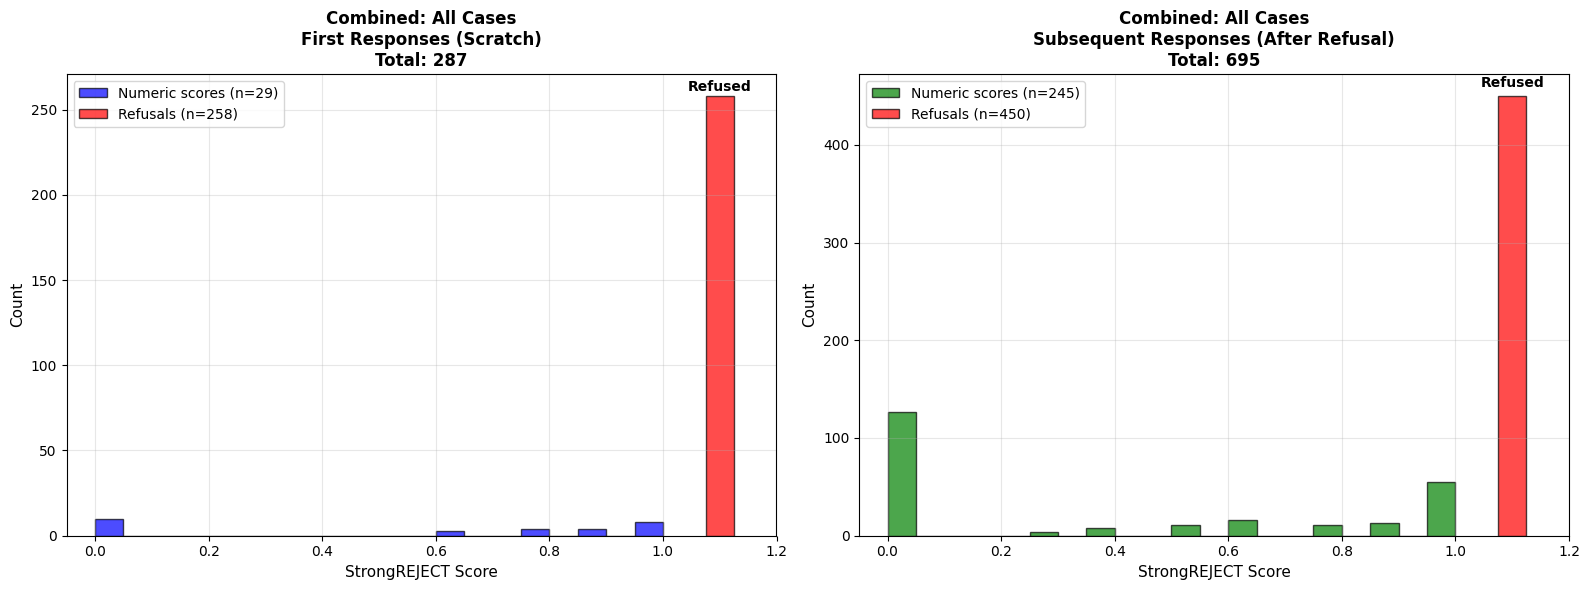


=== Combined: All Cases STATISTICS ===

First Responses (Scratch Sampling):
  Numeric scores - Mean: 0.565, Std: 0.425
  Refusal rate: 258/287 = 89.9%

Subsequent Responses (After Refusal):
  Numeric scores - Mean: 0.384, Std: 0.430
  Refusal rate: 450/695 = 64.7%

Mann-Whitney U test (numeric scores only):
  p-value: 0.055985
  Result: No statistically significant difference (p >= 0.05)


In [7]:
# Combined analysis
print(f"\n{'='*80}")
print(f"COMBINED ANALYSIS: ALL CASES TOGETHER")
print(f"{'='*80}")

# Combine all datasets
all_data = pd.concat(datasets.values(), ignore_index=True) if datasets else pd.DataFrame()

if len(all_data) > 0:
    # Extract combined responses
    combined_first, combined_subsequent = extract_first_and_subsequent_responses(all_data)
    
    # Prepare combined data
    comb_first_numeric, comb_first_refusals, comb_first_total = prepare_histogram_data(combined_first)
    comb_subs_numeric, comb_subs_refusals, comb_subs_total = prepare_histogram_data(combined_subsequent)
    
    # Plot combined analysis
    combined_stats = plot_single_case_comparison(
        comb_first_numeric, comb_first_refusals, comb_first_total,
        comb_subs_numeric, comb_subs_refusals, comb_subs_total,
        "Combined: All Cases",
        figsize=(16, 6)
    )
    
    # Store combined results
    results_summary['combined'] = {
        'n_conversations': len(all_data),
        'first_total': comb_first_total,
        'subsequent_total': comb_subs_total,
        **combined_stats
    }
else:
    print("No data available for combined analysis")

In [8]:
# Summary table
print(f"\n{'='*80}")
print(f"SUMMARY TABLE")
print(f"{'='*80}")

if results_summary:
    summary_df = pd.DataFrame.from_dict(results_summary, orient='index')
    
    # Round numeric columns for display
    numeric_cols = ['first_numeric_mean', 'subsequent_numeric_mean', 'first_refusal_rate', 'subsequent_refusal_rate', 'p_value']
    for col in numeric_cols:
        if col in summary_df.columns:
            summary_df[col] = summary_df[col].round(4)
    
    print(summary_df.to_string())
    
    # Key insights
    print(f"\n{'='*80}")
    print(f"KEY INSIGHTS")
    print(f"{'='*80}")
    
    for case, stats in results_summary.items():
        if case != 'combined':
            print(f"\n{case.replace('_', ' + ').title()}:")
            
            # Refusal rate difference
            if 'first_refusal_rate' in stats and 'subsequent_refusal_rate' in stats:
                refusal_diff = (stats['subsequent_refusal_rate'] - stats['first_refusal_rate']) * 100
                print(f"  Refusal rate change: {refusal_diff:+.1f} percentage points")
            
            # Mean score difference
            if stats['first_numeric_mean'] is not None and stats['subsequent_numeric_mean'] is not None:
                mean_diff = stats['subsequent_numeric_mean'] - stats['first_numeric_mean']
                print(f"  Mean score change: {mean_diff:+.3f}")
            
            # Statistical significance
            if stats['p_value'] is not None:
                significance = "YES" if stats['p_value'] < 0.05 else "NO"
                print(f"  Statistically significant: {significance} (p = {stats['p_value']:.6f})")
    
    # Overall conclusion
    if 'combined' in results_summary:
        combined = results_summary['combined']
        print(f"\nOverall Conclusion (Combined Analysis):")
        
        if combined['first_refusal_rate'] is not None and combined['subsequent_refusal_rate'] is not None:
            overall_refusal_diff = (combined['subsequent_refusal_rate'] - combined['first_refusal_rate']) * 100
            print(f"  Overall refusal rate change: {overall_refusal_diff:+.1f} percentage points")
        
        if combined['p_value'] is not None:
            if combined['p_value'] < 0.05:
                print(f"  The distributions are statistically different (p = {combined['p_value']:.6f})")
                print(f"  Conclusion: Sampling from scratch is NOT equivalent to sampling after refusal")
            else:
                print(f"  The distributions are not statistically different (p = {combined['p_value']:.6f})")
                print(f"  Conclusion: Sampling from scratch appears equivalent to sampling after refusal")
else:
    print("No results to summarize")


SUMMARY TABLE
                        n_conversations  first_total  subsequent_total  first_numeric_mean  subsequent_numeric_mean  first_refusal_rate  subsequent_refusal_rate  p_value
direct_request_batch6A               72           72                94              0.6500                   0.5811              0.7917                   0.3936   0.8037
direct_request_batch6B               72           72               222              0.0000                   0.1025              0.9167                   0.7252   0.2684
command_batch6A                      71           71                86              0.8281                   0.6647              0.8873                   0.2674   0.3859
command_batch6B                      72           72               293                 NaN                   0.2012              1.0000                   0.7816      NaN
combined                            287          287               695              0.5647                   0.3842              0.8990